# US Retail Sales - Time Series EDA & Preprocessing

**Data source:** FRED (Federal Reserve Economic Data)
- `RSAFSNA` — Advance Retail Sales: Retail Trade and Food Services, **Not Seasonally Adjusted** (millions of USD, monthly)
- `RSAFS` — same series, **Seasonally Adjusted**

Both run from **January 1992 to the most recent released month** (34+ years, updated monthly).

**Why this pair of series:** having both the NSA and SA versions of the same
underlying data lets us directly compare "raw" seasonality against the
Census Bureau's own seasonal adjustment — useful context before we do our
own stationarity work on the NSA series.

**Setup required before running this notebook:**
1. Get a free API key: https://fred.stlouisfed.org/docs/api/api_key.html
2. Set it as an environment variable (don't hardcode it in the notebook):
   ```bash
   export FRED_API_KEY="your_key_here"
   ```
   (On Windows: `setx FRED_API_KEY "your_key_here"`, then restart the terminal)
3. `pip install fredapi statsmodels pmdarima`

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

api_key = os.environ.get('FRED_API_KEY')
if not api_key:
    raise RuntimeError(
        "FRED_API_KEY environment variable not set. "
        "Get a free key at https://fred.stlouisfed.org/docs/api/api_key.html "
        "and set it with: export FRED_API_KEY='your_key_here'"
    )

fred = Fred(api_key=api_key)


# 1. Fetch the data

In [4]:
retail_nsa = fred.get_series('RSAFSNA')  # Not Seasonally Adjusted
retail_sa = fred.get_series('RSAFS')      # Seasonally Adjusted

df = pd.DataFrame({
    'retail_sales_nsa': retail_nsa,
    'retail_sales_sa': retail_sa,
})
df.index.name = 'date'
df = df.sort_index()

print(df.shape)
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
df.tail(10)


(414, 2)
Date range: 1992-01-01 to 2026-06-01


,retail_sales_nsa,retail_sales_sa
date,,
2025-09-01,708379.0,732192.0
2025-10-01,743117.0,731051.0
2025-11-01,736533.0,734718.0
2025-12-01,816411.0,734717.0
2026-01-01,674374.0,734503.0
2026-02-01,656082.0,741278.0
2026-03-01,761135.0,754013.0
2026-04-01,755742.0,759097.0
2026-05-01,796039.0,766876.0


In [5]:
# Save a local snapshot so later notebooks don't need to re-hit the API every time
os.makedirs('../data/raw', exist_ok=True)
df.to_csv('../data/raw/fred_retail_sales.csv')
print('Saved snapshot to ../data/raw/fred_retail_sales.csv')


Saved snapshot to ../data/raw/fred_retail_sales.csv


# 2. Basic exploration

Check for missing values (a live-updating series can have gaps if a release
is delayed) and look at summary statistics.


In [6]:
print(df.isnull().sum())
print()
print(df.describe())


retail_sales_nsa    0
retail_sales_sa     0
dtype: int64

       retail_sales_nsa  retail_sales_sa
count        414.000000       414.000000
mean      387029.379227    387019.289855
std       161279.955737    159265.544713
min       142051.000000    158647.000000
25%       263206.750000    268416.500000
50%       358431.000000    357553.500000
75%       470185.750000    473874.000000
max       816411.000000    768553.000000


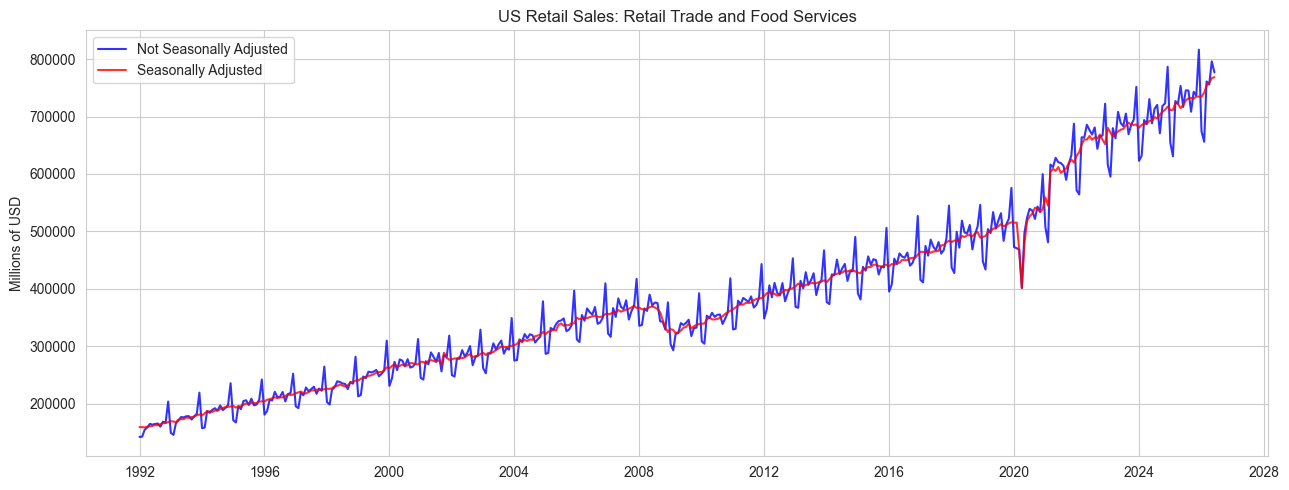

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df['retail_sales_nsa'], label='Not Seasonally Adjusted', color='BLUE', alpha=0.8)
ax.plot(df.index, df['retail_sales_sa'], label='Seasonally Adjusted', color='RED', alpha=0.8)
ax.set_title('US Retail Sales: Retail Trade and Food Services')
ax.set_ylabel('Millions of USD')
ax.legend()
plt.tight_layout()
plt.show()


**What to look for:** the NSA series should show a clear repeating
sawtooth pattern (December holiday-shopping spikes, January drop-offs) that
the SA series smooths out. If both lines look identical, something's wrong
with the fetch (e.g. accidentally pulling the same series twice).


# 3. Recent-period zoom in

The full 34-year history is useful for modeling, but it's worth a separate
look at just the last few years to see the most current dynamics (e.g. any
lingering post-pandemic distortion, current inflation-driven trend).

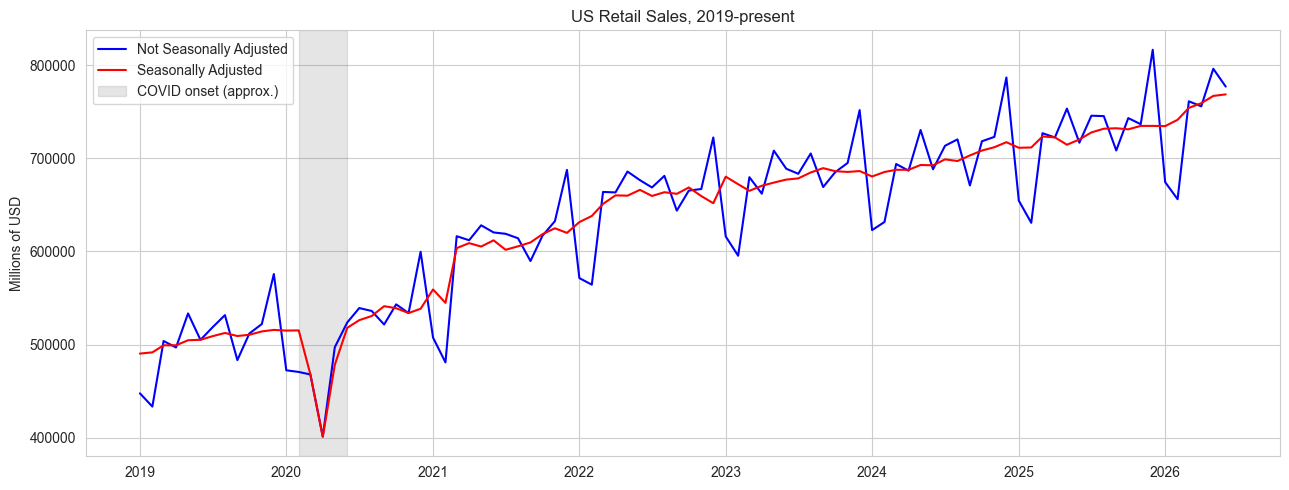

In [8]:
recent = df.loc['2019-01-01':]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(recent.index, recent['retail_sales_nsa'], label='Not Seasonally Adjusted', color='BLUE')
ax.plot(recent.index, recent['retail_sales_sa'], label='Seasonally Adjusted', color='RED')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), color='gray', alpha=0.2, label='COVID onset (approx.)')
ax.set_title('US Retail Sales, 2019-present')
ax.set_ylabel('Millions of USD')
ax.legend()
plt.tight_layout()
plt.show()


# 4. Seasonal decomposition (NSA series)

compare multiplicative vs. additive decomposition and check which leaves a
patternless residual.

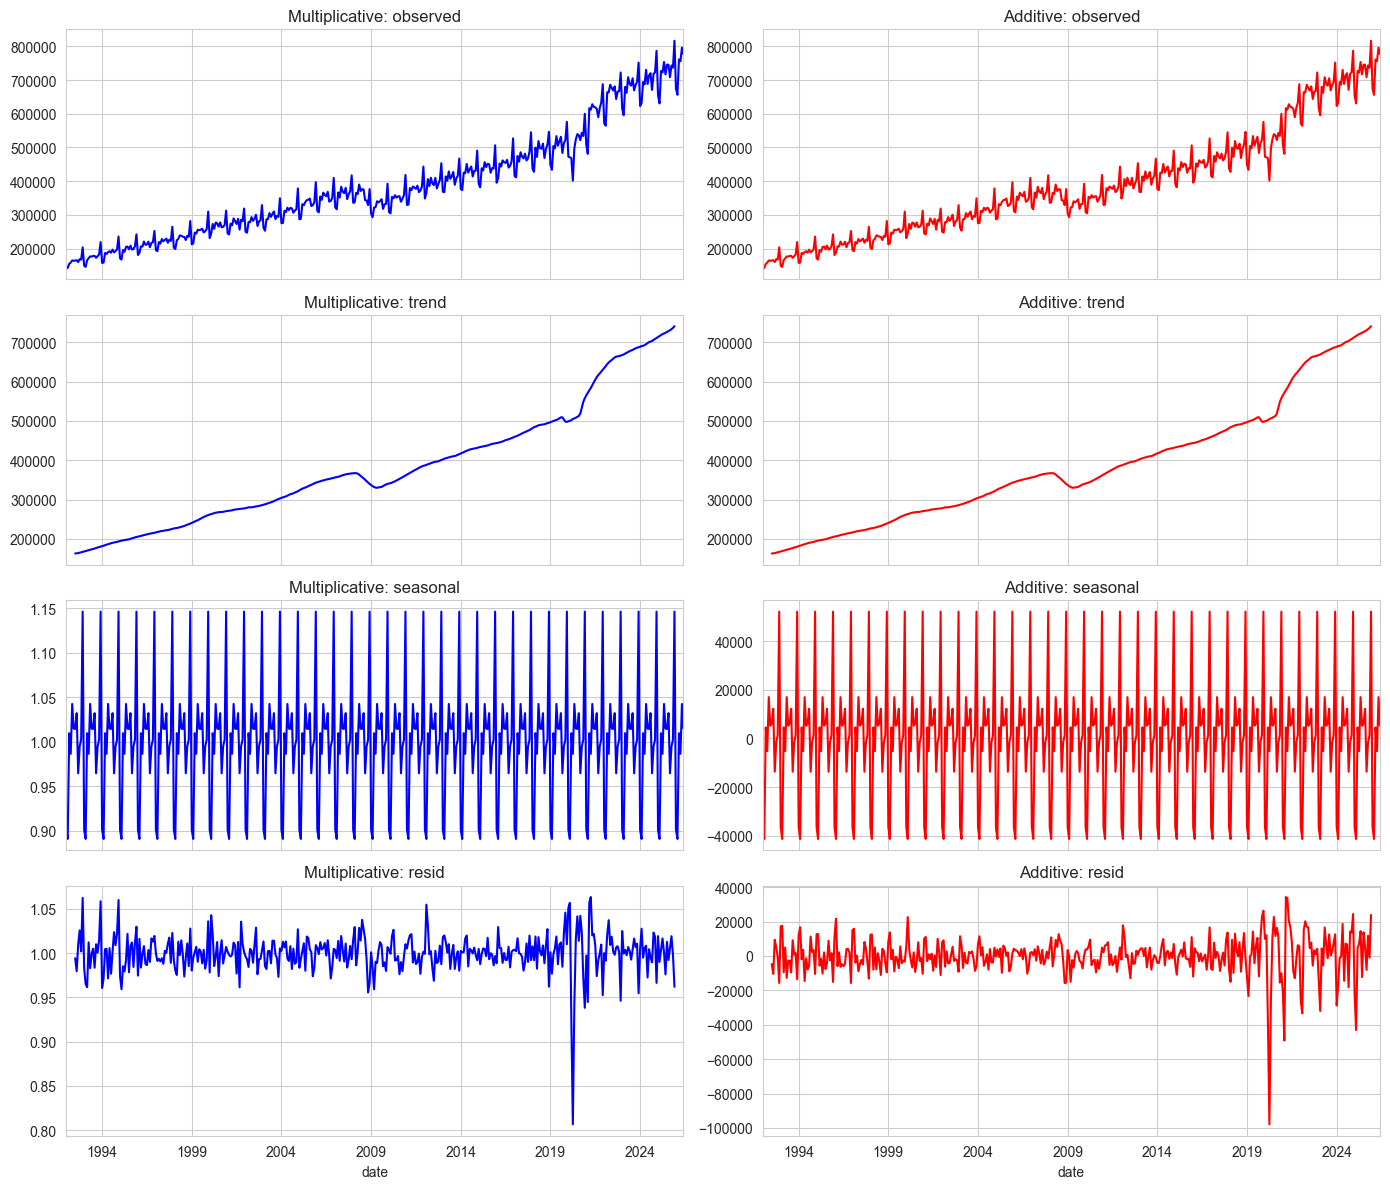

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = df['retail_sales_nsa'].dropna()
series.index.freq = pd.infer_freq(series.index)

decomp_mult = seasonal_decompose(series, model='multiplicative', period=12)
decomp_add = seasonal_decompose(series, model='additive', period=12)

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
components = ['observed', 'trend', 'seasonal', 'resid']
for i, comp in enumerate(components):
    getattr(decomp_mult, comp).plot(ax=axes[i, 0], color='BLUE')
    axes[i, 0].set_title(f'Multiplicative: {comp}')
    getattr(decomp_add, comp).plot(ax=axes[i, 1], color='RED')
    axes[i, 1].set_title(f'Additive: {comp}')
plt.tight_layout()
plt.show()


**Reading this:** check the `resid` (residual) row for both models — the
one with a residual that looks like patternless noise (no visible cyclical
shape, roughly constant spread over time) is the better-fitting
decomposition. Retail sales growth scales with the overall economy over 34
years, so a multiplicative model (where seasonal swings grow proportionally
with the trend) is likely to fit better than additive — but confirm this by
eye rather than assuming it.


# 5. Stationarity check (ADF test)

stationarity, no autocorrelation, and
(ideally) normally distributed residuals. Start with the raw NSA series.

In [12]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f'--- {label} ---')
    print(f'ADF statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Stationary at 5%: {"Yes" if result[1] < 0.05 else "No"}')
    print()
    return result[1]

p_raw = adf_report(df['retail_sales_nsa'], 'Raw NSA series')


--- Raw NSA series ---
ADF statistic: 1.6568
p-value: 0.9980
Stationary at 5%: No



# 6. Rolling statistics and ACF/PACF

Visual checks to accompany the ADF test — a stationary series should have
roughly constant rolling mean/variance over time, and its ACF should decay
quickly rather than staying high across many lags.

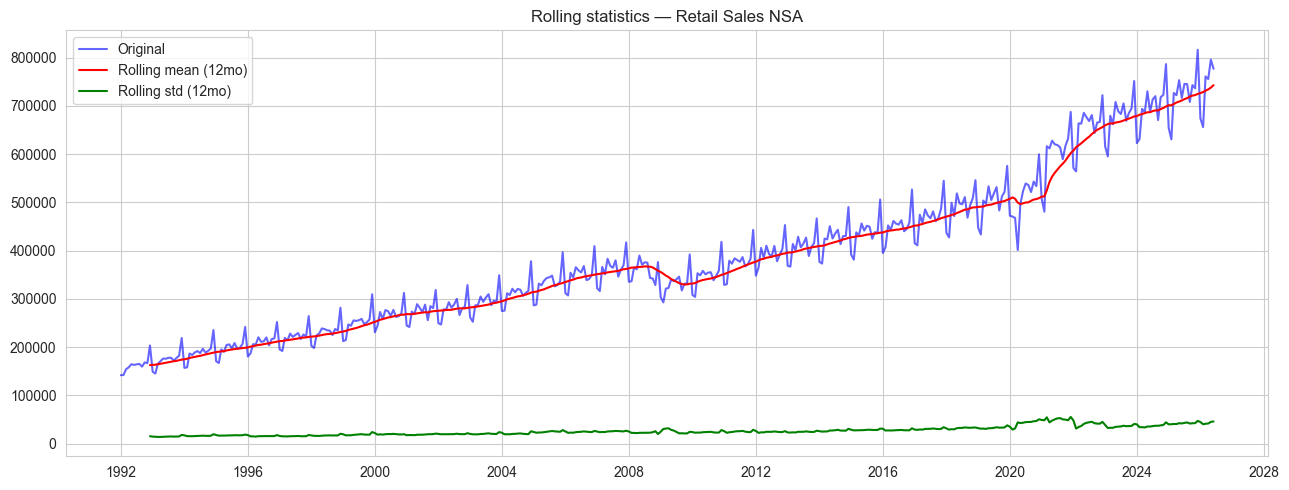

In [13]:
rolling_mean = df['retail_sales_nsa'].rolling(window=12).mean()
rolling_std = df['retail_sales_nsa'].rolling(window=12).std()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df['retail_sales_nsa'], label='Original', color='BLUE', alpha=0.6)
ax.plot(rolling_mean.index, rolling_mean, label='Rolling mean (12mo)', color='RED')
ax.plot(rolling_std.index, rolling_std, label='Rolling std (12mo)', color='GREEN')
ax.set_title('Rolling statistics — Retail Sales NSA')
ax.legend()
plt.tight_layout()
plt.show()


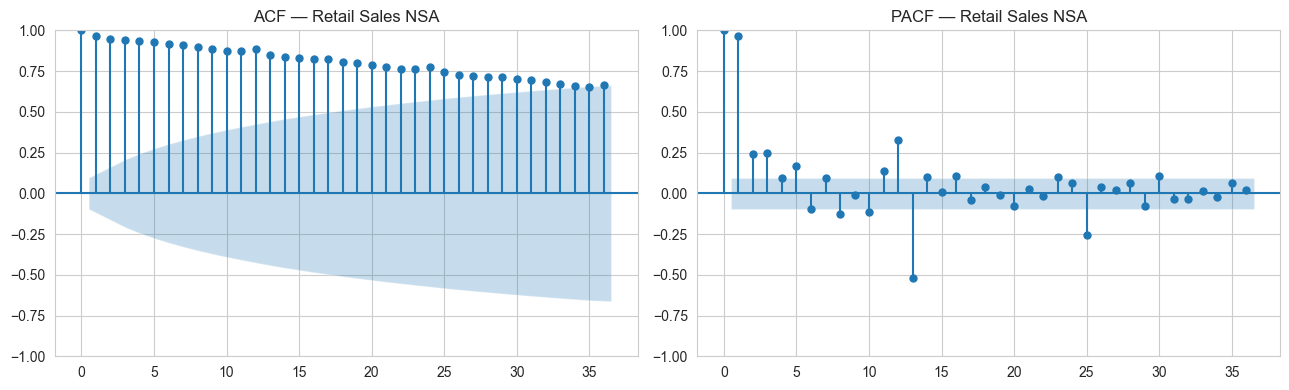

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df['retail_sales_nsa'].dropna(), lags=36, ax=axes[0])
axes[0].set_title('ACF — Retail Sales NSA')
plot_pacf(df['retail_sales_nsa'].dropna(), lags=36, ax=axes[1])
axes[1].set_title('PACF — Retail Sales NSA')
plt.tight_layout()
plt.show()


# Summary: Non-stationarity confirmed, with clear direction for next steps

**ADF test:** ADF statistic = 1.657, p-value = 0.998 — nowhere close to the
0.05 threshold. The raw NSA series is **strongly non-stationary**, consistent
with what a visual read already suggested.

**Rolling statistics:** neither the mean nor the standard deviation is
constant over time — both requirements for stationarity are violated:
- The 12-month rolling mean climbs steadily from ~150K (1992) to ~750K
  (2026), tracking the long-run upward trend.
- The 12-month rolling std also grows over time (~15-20K in the 1990s to
  ~40-50K in recent years) rather than staying flat. This isn't just
  "trending" — the *variance* itself is scaling up, which lines up with the
  multiplicative-decomposition finding from the previous section (seasonal
  swings grow proportionally with the sales level, not by a fixed dollar
  amount). This is a useful cross-check: two different diagnostics
  (decomposition residual shape, rolling variance) are pointing at the same
  conclusion independently.

**ACF/PACF:**
- The ACF decays extremely slowly — still around 0.65-0.7 at lag 36 (3
  years out) rather than dropping toward zero. This slow, near-linear decay
  is the classic signature of a trend/unit-root problem, not just seasonality.
- The PACF cuts off sharply after lag 1 (~0.97), typical of a strong AR(1)-like
  unit-root process — this is what first-differencing is designed to remove.
- The PACF also shows a distinct spike at lag 12 (~+0.3) and lag 13
  (~-0.5), a signature of leftover seasonal structure at the 12-month period,
  on top of the trend problem.

**What this means for the next notebook:** the ACF/PACF pattern suggests we'll
need **both** a regular (first) difference — to remove the slow-decaying
trend/unit-root component the sharp PACF cutoff points to — **and** a seasonal
difference at lag 12 — to remove the periodic spike the PACF shows at lags
12-13. This matches the original tutorial's approach (log transform → 1st
difference → seasonal difference) rather than expecting a single simple
transform (log, sqrt, Box-Cox alone) to be enough — worth testing each step
individually with its own ADF check rather than assuming the full combination
is necessary up front.